In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BIT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

In [4]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake["label"] = 0
real["label"] = 1

In [7]:
df = pd.concat([fake, real])

In [8]:
df = df.sample(frac=1)

df.reset_index(inplace=True)

df.drop(["index"], axis=1, inplace=True)

In [9]:
df = df[['text', 'label']]

In [10]:
df.head()

,text,label
0,"Michelle Obama is hands-down, the most divisiv...",0
1,"Anthony Weiner, the husband of Hillary Clinton...",0
2,This is why no one should vote for a Republica...,0
3,While vice-president Mike Pence gave a commenc...,0
4,GENEVA (Reuters) - A spokeswoman for Internati...,1


In [11]:
stop_words = stopwords.words('english')

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [12]:
df['text'] = df['text'].apply(clean_text)

In [13]:
X = df['text']

y = df['label']

In [14]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.988641425389755


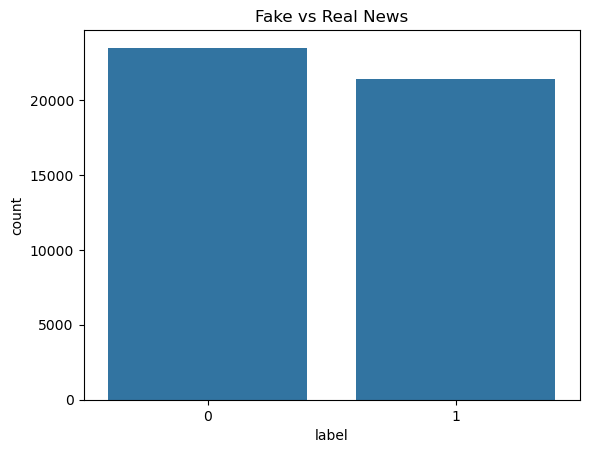

In [19]:
sns.countplot(x='label', data=df)

plt.title("Fake vs Real News")

plt.show()

In [20]:
news = ["Breaking news about election"]

news = [clean_text(news[0])]

news_vector = vectorizer.transform(news)

prediction = model.predict(news_vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("Real News")

Fake News


In [25]:
news = ["The Reserve Bank of India announced on Friday that interest rates will remain unchanged to support economic growth while controlling inflation. Officials stated that the banking sector remains stable and financial conditions are improving across the country."]
news = [clean_text(news[0])]

news_vector = vectorizer.transform(news)

prediction = model.predict(news_vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("Real News")

print(prediction)

Real News
[1]
